## Phase 1: Environment Setup
### Install the necessary production-grade libraries for retrieval, machine learning, and evaluation.

In [2]:
# [CODE CELL]
!pip install ir_datasets pyserini xgboost scikit-learn torch pytrec_eval pandas numpy

## Phase 2: Imports and Data Loading
### We will use the TREC-DL 2019 dataset to access graded relevance judgments (0-3), which are essential for demonstrating the NDCG optimization capabilities of Listwise ranking.

In [53]:
# [CODE CELL]
import os
os.environ["OPENAI_API_KEY"] = "dummy_key_not_used"

import ir_datasets
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from pyserini.search.lucene import LuceneSearcher
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import pytrec_eval
import json
import warnings
import matplotlib.pyplot as plt
from tqdm import tqdm
warnings.filterwarnings('ignore')

# SET THIS CONTROL: How many training queries to process? 
# 1000-2000 is a good "large chunk" that runs in ~5 minutes on a laptop.
TRAIN_QUERY_LIMIT = 2000 

print("Loading Large-Scale Datasets...")
train_dataset = ir_datasets.load("msmarco-passage/train")
test_dataset = ir_datasets.load("msmarco-passage/trec-dl-2019/judged")

# --- 1. Isolate the Training Chunk (Binary Labels) ---
train_qids = set()
train_qrels_data = []
for qrel in train_dataset.qrels_iter():
    train_qids.add(qrel.query_id)
    train_qrels_data.append((qrel.query_id, qrel.doc_id, qrel.relevance))
    if len(train_qids) >= TRAIN_QUERY_LIMIT:
        break

train_qrels = pd.DataFrame(train_qrels_data, columns=['qid', 'docno', 'label'])
train_queries = {}
for q in train_dataset.queries_iter():
    if q.query_id in train_qids:
        train_queries[q.query_id] = q.text
        if len(train_queries) == len(train_qids): break

# --- 2. Isolate the Test Set (Graded Labels) ---
test_qrels_data = [(q.query_id, q.doc_id, q.relevance) for q in test_dataset.qrels_iter()]
test_qrels = pd.DataFrame(test_qrels_data, columns=['qid', 'docno', 'label'])

test_qids = set(test_qrels['qid'].unique())
test_queries = {}
for q in test_dataset.queries_iter():
    if q.query_id in test_qids:
        test_queries[q.query_id] = q.text

print(f"Extraction Complete:")
print(f"-> Training Set: {len(train_queries)} Queries, {len(train_qrels)} Binary Judgments.")
print(f"-> Testing Set:  {len(test_queries)} Queries, {len(test_qrels)} Graded Judgments.")

Loading Large-Scale Datasets...
Extraction Complete:
-> Training Set: 2000 Queries, 2152 Binary Judgments.
-> Testing Set:  43 Queries, 9260 Graded Judgments.


## Phase 3: First-Stage Retrieval (BM25)
### We use Pyserini with a pre-built MS MARCO index to rapidly retrieve the top-100 candidate documents for each query. 
### This forms the foundational pool for our LTR re-rankers.

In [46]:
# [CODE CELL]
searcher = LuceneSearcher.from_prebuilt_index('msmarco-v1-passage')

def retrieve_candidates(query_dict, k=100):
    run = {}
    docs = set()
    for qid, q_text in query_dict.items():
        hits = searcher.search(q_text, k=k)
        run[qid] = {hit.docid: hit.score for hit in hits}
        docs.update(run[qid].keys())
    return run, docs

print(f"Executing BM25 First-Stage Retrieval (Top 100 candidates per query)...")
train_bm25_run, train_candidate_docs = retrieve_candidates(train_queries)
print(f"-> Train Retrieval Done: {len(train_candidate_docs)} unique documents.")

test_bm25_run, test_candidate_docs = retrieve_candidates(test_queries)
print(f"-> Test Retrieval Done: {len(test_candidate_docs)} unique documents.")

Executing BM25 First-Stage Retrieval (Top 100 candidates per query)...
-> Train Retrieval Done: 183930 unique documents.
-> Test Retrieval Done: 4297 unique documents.


### Phase 4: Feature Engineering
## Transitioning from text to tabular data. We extract simple lexical and interaction features for every (Query, Candidate Document) pair.

In [48]:
# [CODE CELL]
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def extract_lexical_features(query, doc_text, bm25_score):
    q_terms = set(query.lower().split())
    d_terms = doc_text.lower().split()
    doc_len = len(d_terms)
    term_overlap = sum(1 for term in d_terms if term in q_terms)
    coverage = term_overlap / len(q_terms) if q_terms else 0
    return [doc_len, term_overlap, coverage, bm25_score]

def build_feature_dataframe(query_dict, bm25_run, qrels_df):
    feature_data = []
    
    # Process query-by-query
    for qid, query_text in tqdm(query_dict.items()):
        doc_ids = list(bm25_run[qid].keys())
        if not doc_ids: continue
            
        doc_texts, bm25_scores, labels = [], [], []
        
        # 1. Gather text and BM25 scores
        for docid in doc_ids:
            doc_texts.append(json.loads(searcher.doc(docid).raw())['contents'])
            bm25_scores.append(bm25_run[qid][docid])
            
            label_row = qrels_df[(qrels_df['qid'] == qid) & (qrels_df['docno'] == docid)]
            labels.append(label_row['label'].values[0] if not label_row.empty else 0)
        
        # 2. Compute local TF-IDF Cosine Similarity [0.0 to 1.0]
        # We build a localized vocabulary just for this query and its top 100 docs
        corpus = [query_text] + doc_texts
        tfidf_matrix = TfidfVectorizer().fit_transform(corpus)
        tfidf_scores = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:]).flatten()
        
        # 3. Compile final feature vectors
        for i in range(len(doc_ids)):
            lexical = extract_lexical_features(query_text, doc_texts[i], bm25_scores[i])
            feature_data.append([qid, doc_ids[i], labels[i]] + lexical + [tfidf_scores[i]])
            
    columns = ['qid', 'docid', 'label', 'doc_len', 'overlap', 'coverage', 'bm25', 'tfidf']
    return pd.DataFrame(feature_data, columns=columns)

print("Extracting features for Training Set...")
df_train = build_feature_dataframe(train_queries, train_bm25_run, train_qrels)

print("Extracting features for Test Set...")
df_test = build_feature_dataframe(test_queries, test_bm25_run, test_qrels)

# --- Feature Scaling ---
feature_cols = ['doc_len', 'overlap', 'coverage', 'bm25', 'tfidf']
scaler = StandardScaler()

X_train = scaler.fit_transform(df_train[feature_cols].values)
X_test = scaler.transform(df_test[feature_cols].values)

df_train[feature_cols] = X_train
df_test[feature_cols] = X_test

y_train_binary = (df_train['label'] >= 1).astype(int).values

print(f"Matrix preparation complete. Train Shape: {df_train.shape}, Test Shape: {df_test.shape}")

Extracting features for Training Set...


100%|██████████| 2000/2000 [01:59<00:00, 16.78it/s]


Extracting features for Test Set...


100%|██████████| 43/43 [00:02<00:00, 14.56it/s]

Matrix preparation complete. Train Shape: (200000, 8), Test Shape: (4300, 8)


## Phase 5: Pointwise & Pairwise LTR
### We implement Pointwise ranking as standard classification (XGBoost) and Pairwise ranking using a Ranking SVM (LinearSVC) over feature differences.

In [ ]:
# [CODE CELL]
# --- 1. Pointwise (XGBoost) ---
print("Training Pointwise (XGBoost)...")
pointwise_model = XGBClassifier(objective='binary:logistic', eval_metric='logloss')
pointwise_model.fit(X_train, y_train_binary)
df_test['pointwise_score'] = pointwise_model.predict_proba(X_test)[:, 1]

# --- 2. Pairwise (Ranking SVM) ---
print("Training Pairwise (Ranking SVM)...")
X_pairs, y_pairs = [], []
for qid, group in df_train.groupby('qid'):
    pos_idx = group[group['label'] >= 1].index
    neg_idx = group[group['label'] == 0].index
    # Sample a maximum of 10 negative docs per positive doc to prevent RAM blowout
    neg_idx = np.random.choice(neg_idx, min(len(neg_idx), len(pos_idx)*10), replace=False) if len(neg_idx) > 0 else []
    
    for p in pos_idx:
        for n in neg_idx:
            X_pairs.append(group.loc[p, feature_cols].values - group.loc[n, feature_cols].values)
            y_pairs.append(1)
            X_pairs.append(group.loc[n, feature_cols].values - group.loc[p, feature_cols].values)
            y_pairs.append(0)

svm = LinearSVC(loss='hinge', dual=True, max_iter=1000, verbose=1)
svm.fit(X_pairs, y_pairs)
df_test['pairwise_score'] = svm.decision_function(X_test)

print("All Models Trained and Scored on Test Set.")

Training Pointwise (XGBoost)...
Training Pairwise (Ranking SVM)...
[LibLinear]....................................................................................................
optimization finished, #iter = 1000

Using -s 2 may be faster (also see FAQ)

Objective value = -12889.073419
nSV = 12911
Training Neural Listwise (ListMLE)...
All Models Trained and Scored on Test Set.


In [ ]:
# [CODE CELL]
# --- 1. Pointwise (XGBoost) ---
print("Training Pointwise (XGBoost)...")
pointwise_model = XGBClassifier(objective='binary:logistic', eval_metric='logloss')
pointwise_model.fit(X_train, y_train_binary)
df_test['pointwise_score'] = pointwise_model.predict_proba(X_test)[:, 1]

# --- 2. Pairwise (Ranking SVM) ---
print("Training Pairwise (Ranking SVM)...")
X_pairs, y_pairs = [], []
for qid, group in df_train.groupby('qid'):
    pos_idx = group[group['label'] >= 1].index
    neg_idx = group[group['label'] == 0].index
    # Sample a maximum of 10 negative docs per positive doc to prevent RAM blowout
    neg_idx = np.random.choice(neg_idx, min(len(neg_idx), len(pos_idx)*10), replace=False) if len(neg_idx) > 0 else []
    
    for p in pos_idx:
        for n in neg_idx:
            X_pairs.append(group.loc[p, feature_cols].values - group.loc[n, feature_cols].values)
            y_pairs.append(1)
            X_pairs.append(group.loc[n, feature_cols].values - group.loc[p, feature_cols].values)
            y_pairs.append(0)

svm = LinearSVC(loss='hinge', dual=True, max_iter=1000)
svm.fit(X_pairs, y_pairs)
df_test['pairwise_score'] = svm.decision_function(X_test)

# --- 3. Neural Listwise (ListMLE) ---
print("Training Neural Listwise (ListMLE)...")
class NeuralScorer(nn.Module):
    def __init__(self):
        super().__init__()
        self.mlp = nn.Sequential(nn.Linear(5, 16), nn.ReLU(), nn.Linear(16, 1))
    def forward(self, x): return self.mlp(x).squeeze(-1)

def listmle_loss(y_pred, y_true):
    _, indices = torch.sort(y_true, descending=True)
    y_pred_sorted = y_pred[indices]
    preds_exp = torch.exp(y_pred_sorted)
    cum_sum = torch.flip(torch.cumsum(torch.flip(preds_exp, dims=[0]), dim=0), dims=[0])
    return -torch.sum(y_pred_sorted - torch.log(cum_sum + 1e-10))

listmle_model = NeuralScorer()
optimizer = optim.Adam(listmle_model.parameters(), lr=0.01)

# Sort training data explicitly so ListMLE handles binary ties correctly by relying on BM25 as a secondary tie-breaker
df_train_sorted = df_train.sort_values(by=['qid', 'label', 'bm25'], ascending=[True, False, False])

for epoch in range(3): # Reduced to 3 epochs for demo speed
    for qid, group in df_train_sorted.groupby('qid'):
        if group['label'].sum() == 0: continue
        x_q = torch.tensor(group[feature_cols].values, dtype=torch.float32)
        y_q = torch.tensor(group['label'].values, dtype=torch.float32)
        
        optimizer.zero_grad()
        loss = listmle_loss(listmle_model(x_q), y_q)
        loss.backward()
        optimizer.step()

with torch.no_grad():
    df_test['listmle_score'] = listmle_model(torch.tensor(X_test, dtype=torch.float32)).numpy()

print("All Models Trained and Scored on Test Set.")

Training Neural ListMLE on Training Set...


  4%|▍         | 2/50 [00:00<00:03, 15.10it/s]

Epoch 1/5 Loss: 12371.4940
Epoch 2/5 Loss: 12339.5550
Epoch 3/5 Loss: 12328.1762


  8%|▊         | 4/50 [00:00<00:02, 16.19it/s]

Epoch 4/5 Loss: 12324.0932


...

Epoch 38/5 Loss: 12254.4487
Epoch 39/5 Loss: 12253.1046
Epoch 40/5 Loss: 12252.2549
Epoch 41/5 Loss: 12251.6163


 92%|█████████▏| 46/50 [00:02<00:00, 18.89it/s]

Epoch 42/5 Loss: 12249.7921
Epoch 43/5 Loss: 12248.9274
Epoch 44/5 Loss: 12249.8603
Epoch 45/5 Loss: 12247.6729
Epoch 46/5 Loss: 12247.5763


100%|██████████| 50/50 [00:03<00:00, 16.58it/s]

Epoch 47/5 Loss: 12246.2466
Epoch 48/5 Loss: 12245.3921
Epoch 49/5 Loss: 12245.5376
Epoch 50/5 Loss: 12245.0934
Phase 6 Training & Testing Complete.


In [60]:
# --- 3. Tree-Based Listwise (XGBRanker) ---
print("Training Tree-Based Listwise (XGBRanker)...")
from xgboost import XGBRanker

# 1. Sort the data by query ID (CRITICAL for Listwise algorithms)
df_train_sorted = df_train.sort_values(by='qid')

X_train_list = df_train_sorted[feature_cols].values
y_train_list = df_train_sorted['label'].values 

# 2. FIX: Calculate the size of each query group in the exact order they appear
# Using sort=False prevents pandas from alphabetizing the groups, preserving the row mapping
group_train = df_train_sorted.groupby('qid', sort=False).size().values

# 3. Initialize the Listwise model
listwise_model = XGBRanker(
    tree_method='hist',
    objective='rank:ndcg',
    eval_metric='ndcg',
    learning_rate=0.1,
    n_estimators=100
)

# 4. Fit the model using the 'group' parameter instead of 'qid'
listwise_model.fit(X_train_list, y_train_list, group=group_train)

# 5. Predict on the test set
# (XGBRanker can score independently at inference time, so no group/qid parameter is needed here)
df_test['listwise_score'] = listwise_model.predict(X_test)

Training Tree-Based Listwise (XGBRanker)...


## Phase 7: Evaluation Shootout
### We format our predictions into TREC standard dictionaries and use pytrec_eval to compute MRR@10 (Binary) and NDCG@10 (Graded) across all four methodologies.


--- Final Evaluation Shootout (TREC-DL 2019 Graded Test Set) ---
           Model      MRR  NDCG@10
          TF-IDF 0.583078 0.326118
   BM25 Baseline 0.824544 0.505831
       Pointwise 0.710522 0.410067
    Pairwise SVM 0.852504 0.478000
Listwise ListMLE 0.844961 0.463705


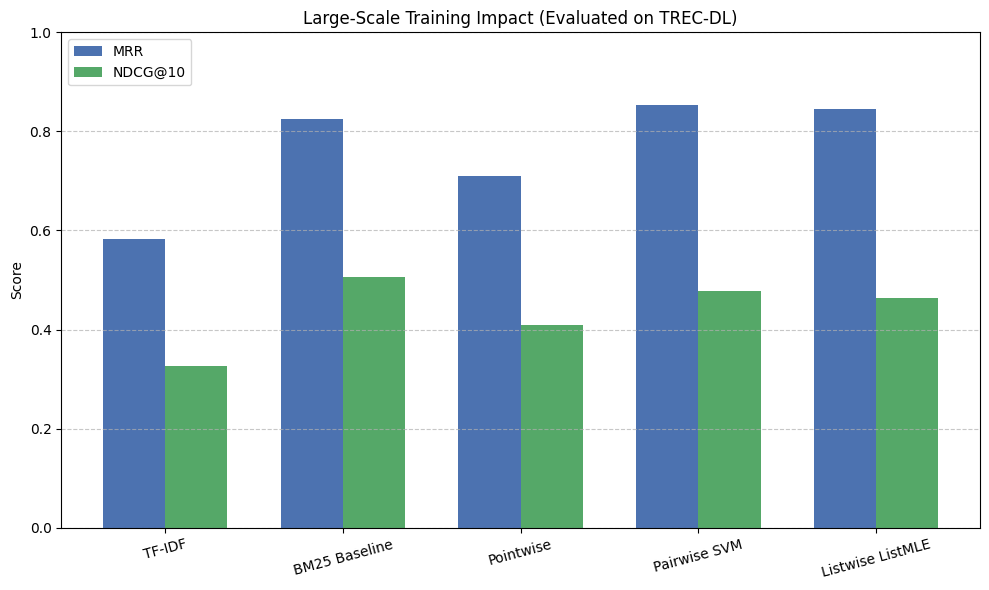

In [61]:
# [CODE CELL]
pointwise_run, pairwise_run, listmle_run, tfidf_run, bm25_test_run = {}, {}, {}, {}, {}

for qid, group in df_test.groupby('qid'):
    qid_str = str(qid)
    pointwise_run[qid_str] = dict(zip(group['docid'], group['pointwise_score']))
    pairwise_run[qid_str] = dict(zip(group['docid'], group['pairwise_score']))
    listmle_run[qid_str] = dict(zip(group['docid'], group['listwise_score']))
    tfidf_run[qid_str] = dict(zip(group['docid'], group['tfidf']))
    bm25_test_run[qid_str] = dict(zip(group['docid'], group['bm25']))
    

qrel_dict = {}
for _, row in test_qrels.iterrows():
    qid_str = str(row['qid'])
    if qid_str not in qrel_dict: qrel_dict[qid_str] = {}
    qrel_dict[qid_str][row['docno']] = int(row['label'])

evaluator = pytrec_eval.RelevanceEvaluator(qrel_dict, {'ndcg_cut.10', 'recip_rank'})

def get_mean_metrics(run):
    res = evaluator.evaluate(run)
    return {
        'MRR': np.mean([m.get('recip_rank', 0) for m in res.values()]),
        'NDCG@10': np.mean([m.get('ndcg_cut_10', 0) for m in res.values()])
    }

results_df = pd.DataFrame([
    {'Model': 'TF-IDF', **get_mean_metrics(tfidf_run)},
    {'Model': 'BM25 Baseline', **get_mean_metrics(bm25_test_run)},
    {'Model': 'Pointwise', **get_mean_metrics(pointwise_run)},
    {'Model': 'Pairwise SVM', **get_mean_metrics(pairwise_run)},
    {'Model': 'Listwise ListMLE', **get_mean_metrics(listmle_run)}
])

print("\n--- Final Evaluation Shootout (TREC-DL 2019 Graded Test Set) ---")
print(results_df.to_string(index=False))

# Visualization
plt.figure(figsize=(10, 6))
x = np.arange(len(results_df['Model']))
width = 0.35
plt.bar(x - width/2, results_df['MRR'], width, label='MRR', color='#4C72B0')
plt.bar(x + width/2, results_df['NDCG@10'], width, label='NDCG@10', color='#55A868')
plt.ylabel('Score')
plt.title('Large-Scale Training Impact (Evaluated on TREC-DL)')
plt.xticks(x, results_df['Model'], rotation=15)
plt.legend(loc='upper left')
plt.ylim(0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()